In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from shared import init_plt

In [37]:
init_plt()
total_sz = 68719706112
df = pd.read_csv('../../data/block-compression.csv')
df['usage'] = 1 / (df['stored'] / total_sz)
df

,pattern_size,stored,usage
0,16,1075562560,63.891873
1,32,1075587584,63.890386
2,64,2149321600,31.972743
3,128,3223040768,21.321389
4,256,5370534144,12.795693
5,512,9665492480,7.109799
6,1024,18255422016,3.764345
7,2048,35435322048,1.939300
8,4096,68721292288,0.999977
9,8192,68721291584,0.999977


/var/folders/4p/l4d417f150j5x1vx2tlxhbqr0000gq/T/ipykernel_80513/302722502.py:20: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, 120)


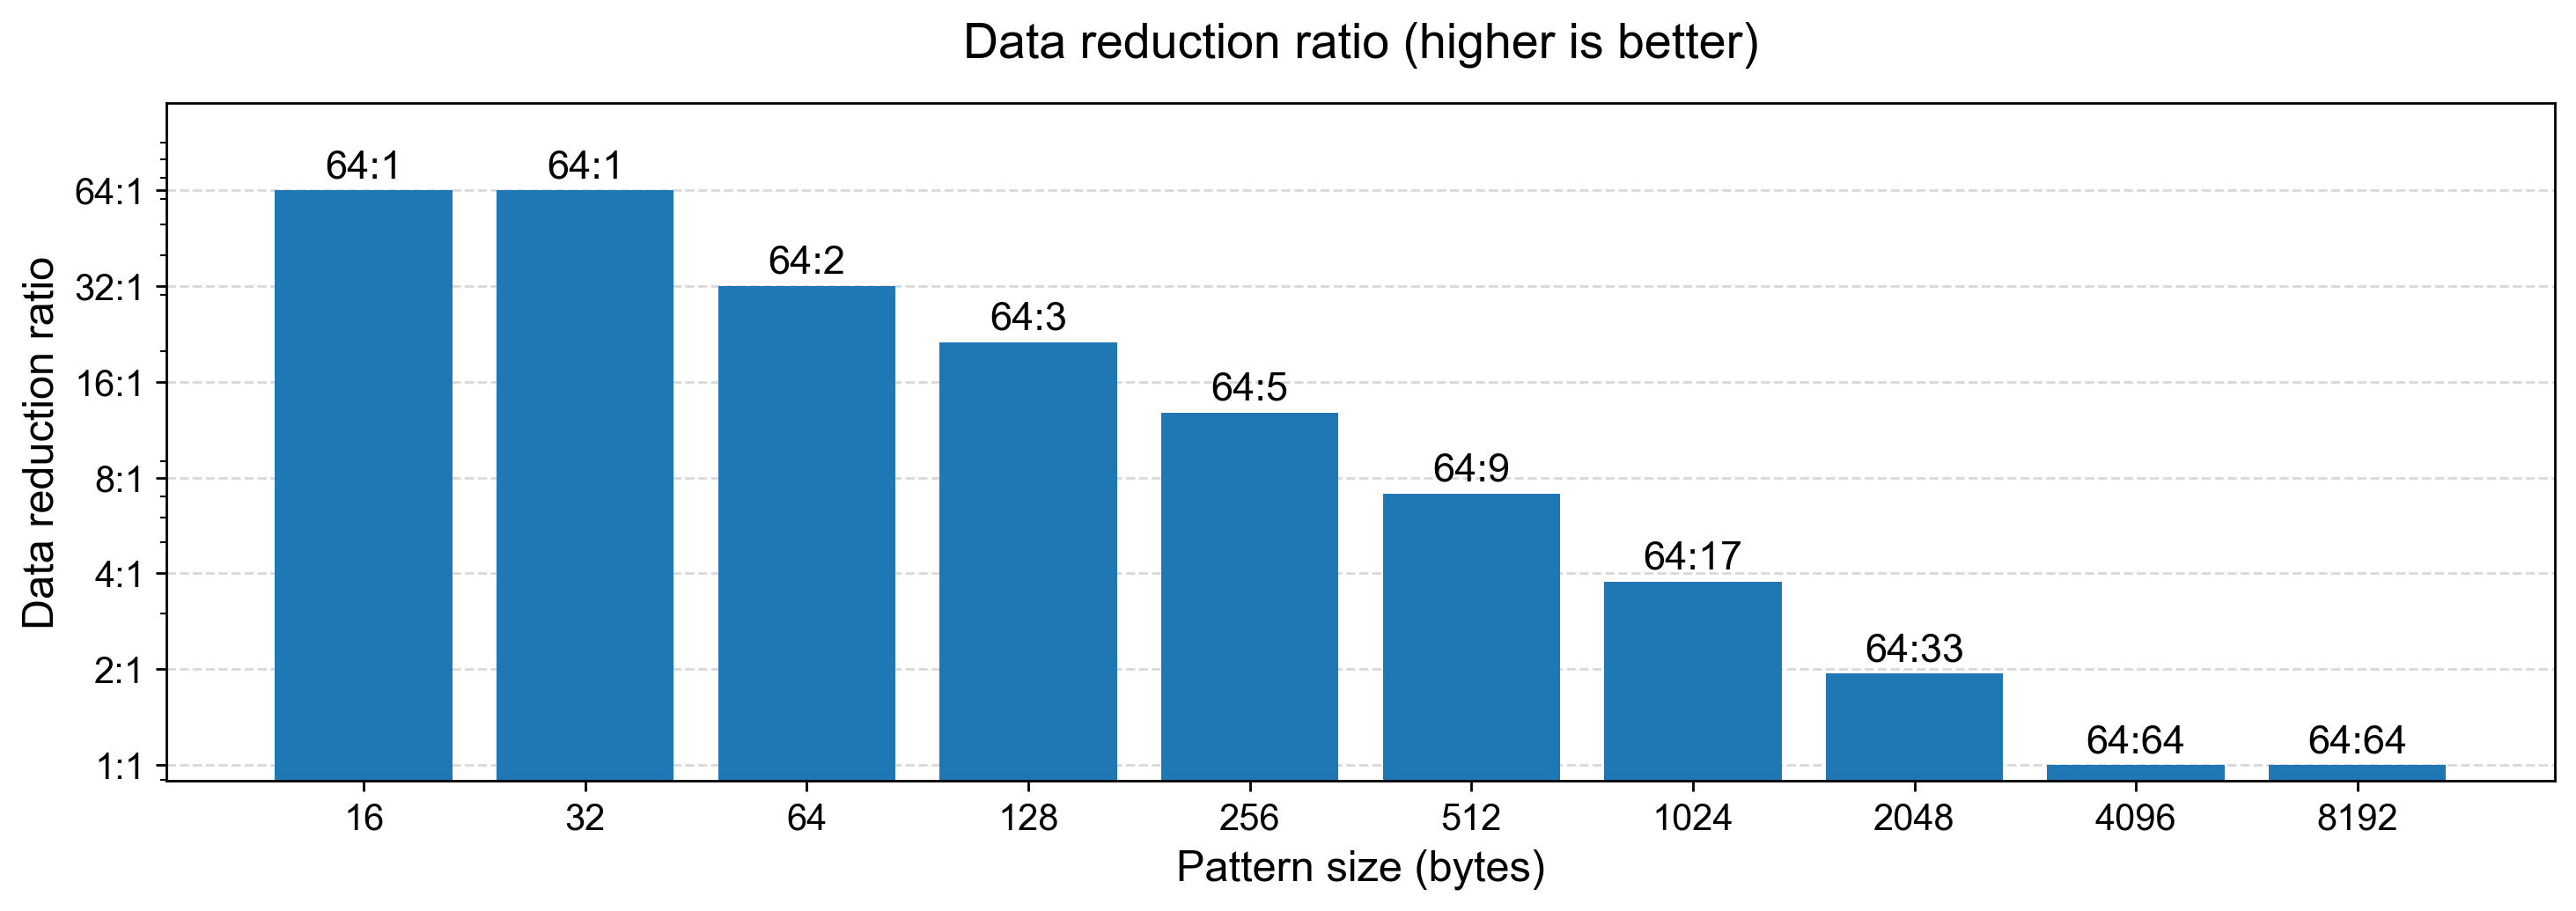

In [75]:
ax: plt.Axes
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(14, 4), dpi=250)

w = 0.3

plt.title("Data reduction ratio (higher is better)", pad=15, size=16)
ax.set_axisbelow(True)

# # x axis
cases = np.arange(len(df.index))
ax.set_xticks(cases, df['pattern_size'])
ax.set_xlabel("Pattern size (bytes)", size=14)

# # y axis
# yticks = range(0, 161, 20)
yticks = [1, 2, 4, 8, 16, 32, 64]
ax.set_ylabel("Data reduction ratio", size=14)
ax.grid(axis='y', which='major', visible=True, linestyle='--', color='grey', alpha=0.3)
ax.set_yscale('log')
ax.set_ylim(0, 120)
ax.set_yticks(yticks, labels=[str(i) + ':1' for i in yticks])

# # bars
ax.bar(cases, df['usage'])

for i, case in enumerate(df.index):
    kw = { 'color': 'black', 'horizontalalignment': 'center', 'size': 13 }
    df_case = df.loc[case]
    gib = '64:' + str(round(df_case['stored'] / (1024 * 1024 * 1024)))
    ax.text(i, df_case['usage'] * 1.1, gib, **kw)

ax.margins(0.05, 0.075)
plt.show()